# Bennett phase-identification methods: five-case comparison

## Objective and classification

This **verification** study implements and compares all five phase-
identification criteria selected by Bennett and Schmidt and applies them to
their five illustrative cases:

1. pure methane \(P\)-\(T\);
2. methane/carbon-dioxide \(P\)-composition at 180 K;
3. impure-CO₂ injection into North Ward Estes oil;
4. the five-component Gozalpour synthetic condensate; and
5. the ten-component ECLIPSE example reservoir fluid.

Success requires the calculated V/L/LV/LL/LLV regions to recover the
topology and method-to-method differences of Figures 2-6, not merely finite
homogeneous-state scores. Following the paper, every feed is therefore
split by a multiphase Gibbs-energy calculation before the selected
identification criterion is applied to every distinct equilibrium phase.
Phase identification remains a diagnostic: it labels the equilibrium phases
but does not enter their material balance or fugacity equations.

## Defining sources and conventions

- Bennett and Schmidt, *Energy & Fuels* 31 (2017), 3370-3379,
  [doi:10.1021/acs.energyfuels.6b02316](https://doi.org/10.1021/acs.energyfuels.6b02316).
- Michelsen and Mollerup, *Thermodynamic Models*, 2nd ed. (2007),
  chapter 12: the printed SRK caption and three-phase state imply different
  \(k_{12}\) conventions; both are tested below.
- Li and Firoozabadi, *SPE Journal* 17 (2012), 1096-1107:
  North Ward Estes component data used by Bennett and Schmidt.
- NIST Chemistry WebBook SRD 69: n-hexadecane critical properties.
- Pedersen, Christensen, and Shaikh, *Phase Behavior of Petroleum
  Reservoir Fluids*, 3rd ed. (2024), Eqs. 5.1-5.5: characterization of
  incomplete ECLIPSE pseudo-component rows.

All public inputs are SI: kelvin, pascal, m³/mol, and kg/mol. Plots show bar
only after the explicit conversion \(1\ {\rm bar}=10^5\ {\rm Pa}\).
Calculations use `torch.float64`.

In [1]:
from __future__ import annotations

import os
import platform
import time
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

import torch_flash
from torch_flash import (
    ChemicalState,
    ComponentSet,
    SCNDistribution,
    component_set,
    identify_phase,
    li_pseudo_critical_temperature,
    negative_flash_residual,
    pedersen_cubic_properties,
    peng_robinson_1978,
    phase_response_derivatives,
    soave_redlich_kwong,
    volume_to_covolume_ratio,
)
from torch_flash.constants import R
from torch_flash.eos import CubicEOS
from torch_flash.initialization import wilson_k_values

torch.set_default_dtype(torch.float64)
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
plt.style.use("seaborn-v0_8-whitegrid")

GRID_POINTS = int(os.environ.get("TORCH_FLASH_PHASE_ID_GRID_POINTS", "33"))
if GRID_POINTS < 3:
    raise ValueError("TORCH_FLASH_PHASE_ID_GRID_POINTS must be at least 3")

reproducibility = pd.Series(
    {
        "torch-flash": torch_flash.__version__,
        "PyTorch": torch.__version__,
        "Python": platform.python_version(),
        "platform": platform.platform(),
        "dtype": str(torch.get_default_dtype()),
        "grid points per axis": GRID_POINTS,
        "PyTorch threads": torch.get_num_threads(),
    },
    name="value",
)
display(reproducibility.to_frame())
print(
    "Set TORCH_FLASH_PHASE_ID_GRID_POINTS=9 for the fast smoke profile or 500 "
    "for the paper's nominal illustrative-grid resolution. The default is 33 x 33."
)

,value
torch-flash,0.1.2
PyTorch,2.12.1
Python,3.13.14
platform,macOS-26.5.2-arm64-arm-64bit-Mach-O
dtype,torch.float64
grid points per axis,33
PyTorch threads,10


Set TORCH_FLASH_PHASE_ID_GRID_POINTS=9 for the fast smoke profile or 500 for the paper's nominal illustrative-grid resolution. The default is 33 x 33.


## The five criteria

Bennett and Schmidt select the following rules:

\[
T_c^{\rm Li}
=r_1\frac{\sum_j x_jV_{c,j}T_{c,j}}{\sum_jx_jV_{c,j}},
\qquad T>T_c^{\rm Li}\ \Rightarrow\ {\rm vapor},
\]

\[
\frac{V}{b}>r_2\ \Rightarrow\ {\rm vapor},
\qquad r_1=1,\quad r_2=1.75,
\]

\[
G(0.5)=\sum_j
\frac{x_j(K_j^{\rm Wilson}-1)}
{1+0.5(K_j^{\rm Wilson}-1)}>0
\ \Rightarrow\ {\rm vapor},
\]

\[
\left(\frac{\partial\kappa}{\partial T}\right)_P>0
\ \Rightarrow\ {\rm liquid},
\qquad
\left(\frac{\partial\alpha}{\partial T}\right)_P>0
\ \Rightarrow\ {\rm liquid}.
\]

Here
\[
\kappa=-\frac{1}{V}\left(\frac{\partial V}{\partial P}\right)_T,
\qquad
\alpha=\frac{1}{V}\left(\frac{\partial V}{\partial T}\right)_P.
\]

`torch-flash` evaluates the last two rules from first and second PyTorch
autodiff derivatives of the explicit EoS pressure \(P(T,V,x)\). For plotting,
every score below is transformed to the same sign convention:
**positive is vapor-like, negative is liquid-like**.

In [2]:
METHODS = {
    "Li pseudo-critical T": "li-pseudo-critical-temperature",
    "Pedersen V/b": "pedersen-volume-to-covolume",
    "Perschke negative flash": "perschke-negative-flash",
    "d(kappa)/dT at P": "pasad-isothermal-compressibility-derivative",
    "d(alpha)/dT at P": "bennett-thermal-expansion-derivative",
}


@dataclass(frozen=True)
class PaperCase:
    """One two-dimensional state family from the comparison paper."""

    name: str
    model: object
    horizontal: torch.Tensor
    vertical_bar: torch.Tensor
    state_from_coordinates: Callable[[torch.Tensor, torch.Tensor], ChemicalState]
    horizontal_label: str
    assumption: str


def pr_consistent_critical_volume(
    critical_temperature: torch.Tensor,
    critical_pressure: torch.Tensor,
) -> torch.Tensor:
    """Return Eq.-of-state-consistent PR critical volumes with Zc=0.3074."""
    return 0.3074 * R * critical_temperature / critical_pressure


def join_component_sets(
    names: tuple[str, ...],
    first: ComponentSet,
    *,
    critical_temperature: torch.Tensor,
    critical_pressure: torch.Tensor,
    acentric_factor: torch.Tensor,
    molar_mass: torch.Tensor,
    critical_volume: torch.Tensor,
) -> ComponentSet:
    """Append explicit pseudo-components to an existing component set."""
    if first.critical_volume is None:
        raise ValueError("base component set requires critical volumes")
    return ComponentSet(
        names,
        torch.cat((first.critical_temperature, critical_temperature)),
        torch.cat((first.critical_pressure, critical_pressure)),
        torch.cat((first.acentric_factor, acentric_factor)),
        torch.cat((first.molar_mass, molar_mass)),
        torch.cat((first.critical_volume, critical_volume)),
    )


def pressure_grid(low: float, high: float) -> torch.Tensor:
    """Return a paper-axis pressure grid in bar."""
    return torch.linspace(low, high, GRID_POINTS)


def linear_grid(low: float, high: float) -> torch.Tensor:
    return torch.linspace(low, high, GRID_POINTS)


def landmark_pressure_grid(
    low: float, high: float, landmark_pressure_bar: float
) -> torch.Tensor:
    """Return a monotone grid that samples a paper-reported invariant pressure."""
    grid = pressure_grid(low, high)
    closest = torch.argmin(torch.abs(grid - landmark_pressure_bar))
    grid[closest] = landmark_pressure_bar
    return torch.sort(grid).values

## Case definitions and parameter audit

The methane and CH₄/CO₂ cases are direct model reconstructions. The North
Ward Estes values are those tabulated by Li and Firoozabadi; because that
table omits \(V_c\), Li's weighting uses the PR-consistent
\(V_c=Z_cRT_c/P_c\), \(Z_c=0.3074\). The Gozalpour case uses the composition
and nonzero BICs printed by Bennett and Schmidt; n-C16 uses NIST critical
properties and \(\omega=0.749\). The ECLIPSE table does not publish
\(T_c,P_c,\omega,V_c\) for its seven lumped fractions, so those are estimated
with the repository's cited Pedersen PR characterization. This last case is
a transparent reconstruction, not an exact ECLIPSE property-table match.

In [3]:
# Case 1: pure methane, PR78.
methane_components = component_set(("methane",), dtype=torch.float64)
methane_model = peng_robinson_1978(methane_components)
methane_composition = torch.ones(1)


def methane_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, methane_composition)


methane_case = PaperCase(
    "Figure 2 - pure methane P-T",
    methane_model,
    linear_grid(100.0, 1000.0),
    pressure_grid(0.5, 250.0),
    methane_state,
    "temperature / K",
    "Direct PR78 pure-component reconstruction.",
)

In [4]:
# Case 2: methane/carbon dioxide at 180 K, SRK.
#
# Michelsen and Mollerup's Figure 8 caption prints kij=0.08, but their
# independently printed three-phase state at 2.73 MPa
# (x1=0.199, x1II=0.781, y1=0.958) satisfies the standard SRK fugacity
# equations with kij=0.12. The latter is the numerical discriminator used
# here; the residual comparison is reported below.
binary_components = ComponentSet(
    ("methane", "carbon_dioxide"),
    torch.tensor([190.6, 304.2]),
    101325.0 * torch.tensor([45.4, 72.9]),
    torch.tensor([0.008, 0.228]),
    torch.tensor([0.01604, 0.04401]),
    torch.tensor([9.93e-5, 9.40e-5]),
)
binary_kij = torch.tensor([[0.0, 0.12], [0.12, 0.0]])
binary_model = soave_redlich_kwong(binary_components, kij=binary_kij)
BINARY_INVARIANT_NEWTON_TOLERANCE = 1.0e-11


def solve_binary_three_phase_invariant(
    model: CubicEOS,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, int]:
    """Close the binary LLV invariant with an autodiff-Newton solve."""
    roots = ("liquid", "liquid", "vapor")
    temperature = torch.tensor(180.0)

    def residual(variables: torch.Tensor) -> torch.Tensor:
        methane_fractions = torch.sigmoid(variables[:3])
        compositions = torch.stack(
            (methane_fractions, 1.0 - methane_fractions),
            dim=-1,
        )
        pressure = torch.exp(variables[3])
        chemical_potentials = torch.stack(
            tuple(
                torch.log(compositions[index])
                + model.log_fugacity_coefficients(
                    temperature,
                    pressure,
                    compositions[index],
                    roots[index],
                )
                for index in range(3)
            )
        )
        return torch.cat(
            (
                chemical_potentials[1] - chemical_potentials[0],
                chemical_potentials[2] - chemical_potentials[0],
            )
        )

    variables = torch.cat(
        (
            torch.logit(torch.tensor([0.199, 0.781, 0.958])),
            torch.log(torch.tensor([2.73e6])).reshape(1),
        )
    )
    iterations = 0
    for _ in range(12):
        iterations += 1
        current_residual = residual(variables)
        if float(current_residual.abs().max()) <= BINARY_INVARIANT_NEWTON_TOLERANCE:
            break
        step = torch.linalg.solve(
            torch.func.jacrev(residual)(variables),
            -current_residual,
        )
        baseline = float(current_residual.square().sum())
        for line_search in range(14):
            trial = variables + (0.5**line_search) * step
            if float(residual(trial).square().sum()) < baseline:
                variables = trial
                break
        else:
            raise RuntimeError("binary invariant Newton line search failed")
    else:
        raise RuntimeError("binary invariant Newton solve did not converge")

    invariant_residual = residual(variables)
    return (
        torch.exp(variables[3]) / 1.0e5,
        torch.sigmoid(variables[:3]),
        invariant_residual,
        iterations,
    )


(
    binary_invariant_pressure_bar,
    binary_invariant_methane_fractions,
    binary_invariant_residual,
    binary_invariant_iterations,
) = solve_binary_three_phase_invariant(binary_model)


def binary_state(
    methane_fraction: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    composition = torch.stack((methane_fraction, 1.0 - methane_fraction))
    return ChemicalState(torch.tensor(180.0), pressure_bar * 1.0e5, composition)


binary_case = PaperCase(
    "Figure 3 - CH4/CO2 P-x at 180 K",
    binary_model,
    linear_grid(0.001, 0.999),
    landmark_pressure_grid(0.5, 70.0, float(binary_invariant_pressure_bar)),
    binary_state,
    "feed methane mole fraction",
    "Michelsen-Mollerup SRK constants; kij=0.12 selected by their printed "
    "three-phase fugacity-equality state.",
)

In [5]:
# Case 3: 95 mol% CO2 + 5 mol% methane injection into North Ward Estes oil.
nwe_names = (
    "carbon_dioxide",
    "methane",
    "pc1",
    "pc2",
    "pc3",
    "pc4",
    "pc5",
)
nwe_tc = torch.tensor([304.2, 190.6, 343.64, 466.41, 603.07, 733.79, 923.2])
nwe_pc = 1.0e5 * torch.tensor([73.77, 46.0, 45.05, 33.51, 24.24, 18.03, 17.26])
nwe_omega = torch.tensor([0.225, 0.008, 0.13, 0.244, 0.6, 0.903, 1.229])
nwe_molar_mass = 1.0e-3 * torch.tensor(
    [44.01, 16.04, 38.4, 72.82, 135.82, 257.75, 479.95]
)
nwe_components = ComponentSet(
    nwe_names,
    nwe_tc,
    nwe_pc,
    nwe_omega,
    nwe_molar_mass,
    pr_consistent_critical_volume(nwe_tc, nwe_pc),
)
nwe_kij = torch.zeros((7, 7))
nwe_kij[0, 1:] = torch.tensor([0.12, 0.12, 0.12, 0.09, 0.09, 0.09])
nwe_kij[:, 0] = nwe_kij[0]
nwe_model = peng_robinson_1978(nwe_components, kij=nwe_kij)
nwe_oil = torch.tensor([0.0077, 0.2025, 0.1180, 0.1484, 0.2863, 0.1490, 0.0881])
nwe_injection_gas = torch.tensor([0.95, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0])


def nwe_state(
    injected_fraction: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    composition = (
        1.0 - injected_fraction
    ) * nwe_oil + injected_fraction * nwe_injection_gas
    return ChemicalState(torch.tensor(301.48), pressure_bar * 1.0e5, composition)


nwe_case = PaperCase(
    "Figure 4 - North Ward Estes impure-CO2 injection",
    nwe_model,
    linear_grid(0.001, 0.999),
    pressure_grid(50.0, 200.0),
    nwe_state,
    "injected-gas mole fraction",
    "Li-Firoozabadi PR inputs; PR-consistent Vc derived because source table omits Vc.",
)

In [6]:
# Case 4: Gozalpour Batch 2 synthetic condensate.
synthetic_base = component_set(
    ("methane", "propane", "n_pentane", "n_decane"),
    dtype=torch.float64,
)
synthetic_components = join_component_sets(
    ("methane", "propane", "n_pentane", "n_decane", "n_hexadecane"),
    synthetic_base,
    critical_temperature=torch.tensor([722.1]),
    critical_pressure=torch.tensor([1.47985e6]),
    acentric_factor=torch.tensor([0.749]),
    molar_mass=torch.tensor([0.22644116]),
    critical_volume=torch.tensor([1.0e-3]),
)
synthetic_kij = torch.zeros((5, 5))
synthetic_kij[0, 1:] = torch.tensor([0.0140, 0.0236, 0.0501, 0.0370])
synthetic_kij[1, 2:] = torch.tensor([0.0100, 0.0250, 0.0250])
synthetic_kij = synthetic_kij + synthetic_kij.mT
synthetic_model = peng_robinson_1978(synthetic_components, kij=synthetic_kij)
synthetic_composition = torch.tensor([0.8205, 0.0895, 0.0500, 0.0199, 0.0201])


def synthetic_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, synthetic_composition)


synthetic_case = PaperCase(
    "Figure 5 - Gozalpour five-component synthetic fluid",
    synthetic_model,
    linear_grid(100.0, 600.0),
    pressure_grid(1.0, 500.0),
    synthetic_state,
    "temperature / K",
    "Paper composition/BICs; NIST n-C16 critical constants and omega=0.749.",
)

In [7]:
# Case 5: ECLIPSE ten-component reservoir fluid with characterized lumps.
reservoir_pure = component_set(
    ("nitrogen", "carbon_dioxide", "methane"),
    dtype=torch.float64,
)
reservoir_fraction = torch.tensor(
    [0.1515, 0.0703, 0.0867, 0.0529, 0.0340, 0.0238, 0.0145]
)
reservoir_molar_mass = 1.0e-3 * torch.tensor(
    [35.88, 67.98, 110.14, 173.11, 248.85, 361.77, 600.98]
)
reservoir_density = 1.0e3 * torch.tensor(
    [0.9752, 0.6236, 0.7378, 0.7679, 0.8127, 0.8194, 0.8953]
)
reservoir_distribution = SCNDistribution(
    torch.tensor([2, 4, 7, 13, 18, 26, 43]),
    reservoir_fraction,
    reservoir_molar_mass,
    reservoir_density,
)
reservoir_characterized = pedersen_cubic_properties(reservoir_distribution, "PR")
reservoir_components = join_component_sets(
    (
        "nitrogen",
        "carbon_dioxide",
        "methane",
        "c2_c3",
        "c4_c6",
        "c7",
        "c13",
        "c18",
        "c26",
        "c43",
    ),
    reservoir_pure,
    critical_temperature=reservoir_characterized.critical_temperature,
    critical_pressure=reservoir_characterized.critical_pressure,
    acentric_factor=reservoir_characterized.acentric_factor,
    molar_mass=reservoir_molar_mass,
    critical_volume=pr_consistent_critical_volume(
        reservoir_characterized.critical_temperature,
        reservoir_characterized.critical_pressure,
    ),
)
# Table 3 does not publish the ECLIPSE EOS/BIC table. A single transparent
# reconstruction parameter is therefore used to recover Figure 6's defining
# methane-rich/heavy-rich LL split. This is a notebook-specific
# ``bennett-figure6-reconstruction-v1`` parameter, not an ECLIPSE default.
RESERVOIR_METHANE_LUMP_KIJ = 0.06
reservoir_kij = torch.zeros((10, 10))
reservoir_kij[2, 3:] = RESERVOIR_METHANE_LUMP_KIJ
reservoir_kij[3:, 2] = RESERVOIR_METHANE_LUMP_KIJ
reservoir_model = peng_robinson_1978(reservoir_components, kij=reservoir_kij)
reservoir_composition = torch.tensor(
    [0.0069, 0.0314, 0.5280, 0.1515, 0.0703, 0.0867, 0.0529, 0.0340, 0.0238, 0.0145]
)


def reservoir_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, reservoir_composition)


reservoir_case = PaperCase(
    "Figure 6 - characterized ECLIPSE reservoir fluid",
    reservoir_model,
    linear_grid(30.0, 800.0),
    pressure_grid(1.0, 600.0),
    reservoir_state,
    "temperature / K",
    "Paper composition/MW/SG; missing lump critical properties estimated by Pedersen PR; "
    "notebook reconstruction k(CH4,lumps)=0.06. The 0 K plot origin is replaced by the "
    "positive 30 K converged-flash lower bound.",
)

CASES = (methane_case, binary_case, nwe_case, synthetic_case, reservoir_case)

case_audit = pd.DataFrame(
    [
        {
            "case": case.name,
            "components": len(case.model.names),
            "horizontal points": case.horizontal.numel(),
            "pressure points": case.vertical_bar.numel(),
            "assumption": case.assumption,
        }
        for case in CASES
    ]
)
display(case_audit)

,case,components,horizontal points,pressure points,assumption
0,Figure 2 - pure methane P-T,1,33,33,Direct PR78 pure-component reconstruction.
1,Figure 3 - CH4/CO2 P-x at 180 K,2,33,33,Michelsen-Mollerup SRK constants; kij=0.12 sel...
2,Figure 4 - North Ward Estes impure-CO2 injection,7,33,33,Li-Firoozabadi PR inputs; PR-consistent Vc der...
3,Figure 5 - Gozalpour five-component synthetic ...,5,33,33,Paper composition/BICs; NIST n-C16 critical co...
4,Figure 6 - characterized ECLIPSE reservoir fluid,10,33,33,Paper composition/MW/SG; missing lump critical...


In [8]:
figure6_reconstruction_audit = pd.Series(
    {
        "identifier": "bennett-figure6-reconstruction-v1",
        "adjustable parameter": "common PR k(CH4,lumped hydrocarbons)",
        "selected value": RESERVOIR_METHANE_LUMP_KIJ,
        "discrete search": "0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20",
        "calibration target": (
            "Figure 6 topology: high-pressure LL at 100 K plus the adjacent "
            "low-temperature three-phase strip"
        ),
        "calibration class": "visual paper-figure reconstruction; not experimental validation",
        "holdout validation": "none; unpublished ECLIPSE EOS/BIC table remains unavailable",
    },
    name="value",
)
display(figure6_reconstruction_audit.to_frame())

,value
identifier,bennett-figure6-reconstruction-v1
adjustable parameter,"common PR k(CH4,lumped hydrocarbons)"
selected value,0.06
discrete search,"0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20"
calibration target,Figure 6 topology: high-pressure LL at 100 K p...
calibration class,visual paper-figure reconstruction; not experi...
holdout validation,none; unpublished ECLIPSE EOS/BIC table remain...


### Binary-source convention check

The book cited for Figure 3 prints both an SRK caption with \(k_{12}=0.08\)
and, separately, the three-phase state \(P=2.73\) MPa,
\(x_1^{I}=0.199\), \(x_1^{II}=0.781\), \(y_1=0.958\). The table below
evaluates the maximum log-fugacity mismatch of that state without fitting
any other property. It records why this reproduction uses \(k_{12}=0.12\).
A second table reports the nearby invariant state closed to the stated
tolerance by a four-variable PyTorch-autodiff Newton solve. Its pressure is
included explicitly in the otherwise regular Figure 3 pressure grid so the
measure-zero LLV line is not skipped between grid rows.

In [9]:
printed_binary_compositions = torch.tensor(
    [
        [0.199, 0.801],
        [0.781, 0.219],
        [0.958, 0.042],
    ]
)


def printed_three_phase_residual(kij_value: float) -> float:
    kij = torch.tensor([[0.0, kij_value], [kij_value, 0.0]])
    model = soave_redlich_kwong(binary_components, kij=kij)
    temperature = torch.full((3,), 180.0)
    pressure = torch.full((3,), 2.73e6)
    roots = ("liquid", "liquid", "vapor")
    log_fugacities = torch.stack(
        tuple(
            torch.log(composition)
            + model.log_fugacity_coefficients(
                temperature[index],
                pressure[index],
                composition,
                roots[index],
            )
            for index, composition in enumerate(printed_binary_compositions)
        )
    )
    return float((log_fugacities[1:] - log_fugacities[0]).abs().max())


binary_convention_audit = pd.DataFrame(
    [
        {
            "SRK kij": kij_value,
            "max printed-state log-fugacity residual": printed_three_phase_residual(
                kij_value
            ),
        }
        for kij_value in (0.08, 0.12)
    ]
)
display(binary_convention_audit)
assert (
    binary_convention_audit.loc[1, "max printed-state log-fugacity residual"] < 2.0e-2
)
assert (
    binary_convention_audit.loc[0, "max printed-state log-fugacity residual"] > 1.0e-1
)

binary_invariant_audit = pd.Series(
    {
        "pressure / bar": float(binary_invariant_pressure_bar),
        "liquid-I methane fraction": float(binary_invariant_methane_fractions[0]),
        "liquid-II methane fraction": float(binary_invariant_methane_fractions[1]),
        "vapor methane fraction": float(binary_invariant_methane_fractions[2]),
        "maximum log-fugacity residual": float(binary_invariant_residual.abs().max()),
        "autodiff-Newton iterations": binary_invariant_iterations,
    },
    name="value",
)
display(binary_invariant_audit.to_frame())
assert binary_invariant_audit["maximum log-fugacity residual"] <= 1.0e-11

,SRK kij,max printed-state log-fugacity residual
0,0.08,0.218398
1,0.12,0.011857


,value
pressure / bar,2.737022e+01
liquid-I methane fraction,1.949229e-01
liquid-II methane fraction,7.849824e-01
vapor methane fraction,9.584729e-01
maximum log-fugacity residual,2.148282e-14
autodiff-Newton iterations,4.000000e+00


## Grid evaluation

The paper performs a multiphase flash at every feed and then applies the
selected phase-identification criterion to every returned phase. The
repository's public `multiphase_flash` API deliberately fixes the requested
phase count, so this study uses a separate vectorized Gibbs minimization for
phase discovery:

\[
\min_{\{n_{pi}\}}\sum_{p,i}n_{pi}
\left[\ln x_{pi}+\ln\phi_i(T,P,\mathbf{x}_p)\right],
\qquad
n_{pi}=z_i\,{\rm softmax}_p(q_{pi}).
\]

This parameterization enforces nonnegative phase/component amounts and
material balance identically. PyTorch autograd supplies every optimization
gradient. Volatility, component-rich, and a fixed library of 32 randomized
three-phase starts are optimized at **every grid cell** in one batched tensor
calculation. The lowest-Gibbs candidate seeds an autodiff-Newton PT flash
that simultaneously enforces phase normalization, material balance, and
equality of every component fugacity. Duplicate or vanishing phases are
removed only after refinement, and each result must pass explicit residual
gates before it can be colored. A cell that fails the fast Newton path is
retried with strict per-state LBFGS; the timing table reports the fallback
count rather than hiding that work. Finally, any one-phase cell bracketed by
multiphase neighbors is independently reflashed from the best four starts;
the audit repeats until no new bracketed cell appears. A cell is replaced
only when the independent solve finds a lower-Gibbs split that passes the
same residual gates; visual topology never overrides the thermodynamic
objective.
This is a study-level phase-discovery calculation, not a new public flash
API.

In [10]:
@dataclass(frozen=True)
class GridEquilibrium:
    """Padded equilibrium phases and diagnostics over one paper grid."""

    temperatures: torch.Tensor
    pressures: torch.Tensor
    feeds: torch.Tensor
    phase_fractions: torch.Tensor
    phase_compositions: torch.Tensor
    phase_counts: torch.Tensor
    gibbs_reduction: torch.Tensor
    fugacity_residual: torch.Tensor
    material_balance_residual: torch.Tensor
    converged: torch.Tensor
    elapsed_seconds: float
    batched_search_seconds: float
    refinement_seconds: float
    robust_refinement_fallbacks: int
    independent_reflash_audits: int
    independent_reflash_replacements: int


MAX_PHASES = 3
RANDOM_ALLOCATION_STARTS = 32
PHASE_FRACTION_TOLERANCE = 1.0e-4
PHASE_COMPOSITION_MERGE_TOLERANCE = 2.0e-3
GIBBS_REDUCTION_TOLERANCE = 2.0e-7
FUGACITY_RESIDUAL_TOLERANCE = 1.0e-8
FLASH_NEWTON_TOLERANCE = 1.0e-11
INDEPENDENT_REFLASH_STARTS = 4


def _grid_states(case: PaperCase) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    temperatures = []
    pressures = []
    feeds = []
    for pressure_bar in case.vertical_bar:
        for horizontal in case.horizontal:
            state = case.state_from_coordinates(horizontal, pressure_bar)
            temperatures.append(state.temperature)
            pressures.append(state.pressure)
            feeds.append(state.composition)
    return torch.stack(temperatures), torch.stack(pressures), torch.stack(feeds)


def _allocation_initial_logits(
    model: object,
    temperatures: torch.Tensor,
    pressures: torch.Tensor,
    feeds: torch.Tensor,
) -> torch.Tensor:
    """Construct volatility, component-rich, and randomized phase partitions."""
    components = model
    k_values = wilson_k_values(components, temperatures, pressures)
    score = torch.log(k_values)
    score = score - score.mean(dim=-1, keepdim=True)
    score = score / torch.clamp_min(score.abs().amax(dim=-1, keepdim=True), 1.0)

    centers = score.new_tensor([-1.0, 0.0, 1.0])
    starts = []
    for scale in (2.0, 6.0):
        starts.append(-scale * (score[:, None, :] - centers[None, :, None]).square())
    for scale in (2.0, 5.0):
        starts.append(
            torch.stack(
                (
                    -scale * score,
                    scale * score,
                    torch.zeros_like(score),
                ),
                dim=1,
            )
        )

    # Three-phase petroleum states can contain a component-rich liquid that a
    # volatility-only partition misses. Give every component an independent
    # deterministic trial as the third phase; absent/trace feed components are
    # harmless because the component-allocation parameterization preserves
    # their total amounts exactly.
    for component_index in range(feeds.shape[-1]):
        component_rich = torch.stack(
            (
                -1.5 * score,
                1.5 * score,
                torch.full_like(score, -4.0),
            ),
            dim=1,
        )
        component_rich[:, 2, component_index] = 8.0
        starts.append(component_rich)

    generator = torch.Generator(device=score.device)
    generator.manual_seed(20260724)
    for _ in range(RANDOM_ALLOCATION_STARTS):
        random_partition = 5.0 * torch.randn(
            (MAX_PHASES, score.shape[1]),
            dtype=score.dtype,
            device=score.device,
            generator=generator,
        )
        random_logits = (
            random_partition[None, :, :]
            .expand(
                score.shape[0],
                -1,
                -1,
            )
            .clone()
        )
        starts.append(random_logits)
    return torch.stack(starts, dim=1)


def _allocation_quantities(
    model: object,
    temperatures: torch.Tensor,
    pressures: torch.Tensor,
    feeds: torch.Tensor,
    logits: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    bounded_logits = torch.clamp(
        torch.nan_to_num(logits, nan=0.0, posinf=60.0, neginf=-60.0),
        -60.0,
        60.0,
    )
    allocations = torch.softmax(bounded_logits, dim=-2)
    phase_moles = allocations * feeds[:, None, None, :]
    phase_fractions = torch.clamp_min(phase_moles.sum(dim=-1), 1.0e-30)
    phase_compositions = phase_moles / phase_fractions[..., None]
    phase_compositions = torch.clamp_min(phase_compositions, 1.0e-30)
    phase_compositions = phase_compositions / phase_compositions.sum(
        dim=-1,
        keepdim=True,
    )
    expanded_temperature = temperatures[:, None, None].expand_as(phase_fractions)
    expanded_pressure = pressures[:, None, None].expand_as(phase_fractions)
    log_phi = model.log_fugacity_coefficients(
        expanded_temperature,
        expanded_pressure,
        phase_compositions,
        "stable",
    )
    gibbs = torch.sum(
        phase_moles * (torch.log(phase_compositions) + log_phi),
        dim=(-1, -2),
    )
    return gibbs, phase_fractions, phase_compositions


def _merge_candidate_phases(
    fractions: torch.Tensor,
    compositions: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Remove vanishing phases and merge duplicate optimized phases."""
    groups: list[tuple[torch.Tensor, torch.Tensor]] = []
    for phase_index in torch.argsort(fractions, descending=True):
        fraction = fractions[phase_index]
        if float(fraction) <= PHASE_FRACTION_TOLERANCE:
            continue
        composition = compositions[phase_index]
        for group_index, (group_fraction, group_composition) in enumerate(groups):
            if float(torch.max(torch.abs(composition - group_composition))) <= (
                PHASE_COMPOSITION_MERGE_TOLERANCE
            ):
                merged_fraction = group_fraction + fraction
                merged_composition = (
                    group_fraction * group_composition + fraction * composition
                ) / merged_fraction
                groups[group_index] = merged_fraction, merged_composition
                break
        else:
            groups.append((fraction, composition))
    if not groups:
        raise RuntimeError("Gibbs minimization returned no active phase")
    return (
        torch.stack(tuple(item[0] for item in groups)),
        torch.stack(tuple(item[1] for item in groups)),
    )


def _refine_state_allocation(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    initial_logits: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Refine one candidate split to a strict autodiff stationarity tolerance."""
    logits = torch.nn.Parameter(initial_logits.clone())
    optimizer = torch.optim.LBFGS(
        (logits,),
        lr=0.5,
        max_iter=220,
        history_size=20,
        tolerance_grad=2.0e-12,
        tolerance_change=2.0e-15,
        line_search_fn="strong_wolfe",
    )

    def quantities() -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        gibbs, fractions, compositions = _allocation_quantities(
            model,
            temperature[None],
            pressure[None],
            feed[None, :],
            logits[None, None, :, :],
        )
        return gibbs[0, 0], fractions[0, 0], compositions[0, 0]

    def closure() -> torch.Tensor:
        optimizer.zero_grad()
        gibbs, _, _ = quantities()
        gibbs.backward()
        return gibbs

    optimizer.step(closure)
    with torch.no_grad():
        return quantities()


def _logits_from_phases(
    fractions: torch.Tensor,
    compositions: torch.Tensor,
) -> torch.Tensor:
    component_allocations = fractions[:, None] * compositions
    component_allocations = component_allocations / component_allocations.sum(
        dim=0,
        keepdim=True,
    )
    return torch.log(torch.clamp_min(component_allocations, 1.0e-12))


def _flash_quantities(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    variables: torch.Tensor,
    phase_count: int,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Return residual, fractions, compositions, and Gibbs energy for a PT flash."""
    component_count = feed.numel()
    log_k_size = (phase_count - 1) * component_count
    log_k = variables[:log_k_size].reshape(phase_count - 1, component_count)
    fraction_coordinates = variables[log_k_size:]
    fractions = torch.softmax(
        torch.cat((variables.new_zeros(1), fraction_coordinates)),
        dim=0,
    )
    ratios = torch.cat((torch.ones_like(log_k[:1]), torch.exp(log_k)), dim=0)
    denominator = torch.sum(fractions[:, None] * ratios, dim=0)
    raw_compositions = ratios * feed[None, :] / denominator[None, :]
    compositions = raw_compositions / raw_compositions.sum(dim=1, keepdim=True)

    phase_temperature = temperature.expand(phase_count)
    phase_pressure = pressure.expand(phase_count)
    chemical_potentials = torch.log(compositions) + model.log_fugacity_coefficients(
        phase_temperature,
        phase_pressure,
        compositions,
        "stable",
    )
    fugacity_residuals = (chemical_potentials[1:] - chemical_potentials[0]).reshape(-1)
    normalization_residuals = raw_compositions[1:].sum(dim=1) - 1.0
    residual = torch.cat((fugacity_residuals, normalization_residuals))
    phase_moles = fractions[:, None] * compositions
    gibbs = torch.sum(phase_moles * chemical_potentials)
    return residual, fractions, compositions, gibbs


def _refine_phase_equilibrium(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    fractions: torch.Tensor,
    compositions: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Solve material balance and equal fugacity from a Gibbs phase seed."""
    phase_count, component_count = compositions.shape
    if phase_count == 1:
        log_phi = model.log_fugacity_coefficients(
            temperature,
            pressure,
            feed,
            "stable",
        )
        gibbs = torch.sum(feed * (torch.log(feed) + log_phi))
        return fractions, compositions, gibbs

    log_k = torch.log(compositions[1:] / compositions[0]).reshape(-1)
    fraction_coordinates = torch.log(fractions[1:] / fractions[0])
    variables = torch.cat((log_k, fraction_coordinates))
    log_k_size = (phase_count - 1) * component_count

    for _ in range(80):
        residual, current_fractions, current_compositions, gibbs = _flash_quantities(
            model,
            temperature,
            pressure,
            feed,
            variables,
            phase_count,
        )
        residual_norm = residual.detach().abs().max()
        if float(residual_norm) <= FLASH_NEWTON_TOLERANCE:
            return current_fractions, current_compositions, gibbs

        jacobian = torch.func.jacrev(
            lambda current: _flash_quantities(
                model,
                temperature,
                pressure,
                feed,
                current,
                phase_count,
            )[0]
        )(variables)
        try:
            direction = torch.linalg.solve(jacobian, -residual)
        except torch.linalg.LinAlgError:
            regularization = 1.0e-10 * torch.eye(
                variables.numel(),
                dtype=variables.dtype,
                device=variables.device,
            )
            direction = torch.linalg.solve(
                jacobian.mT @ jacobian + regularization,
                -(jacobian.mT @ residual),
            )
        direction_norm = torch.linalg.vector_norm(direction)
        direction = direction * torch.clamp_max(
            direction.new_tensor(8.0) / torch.clamp_min(direction_norm, 1.0),
            1.0,
        )

        accepted = False
        factor = 1.0
        for _ in range(24):
            candidate = variables + factor * direction
            candidate = torch.cat(
                (
                    torch.clamp(candidate[:log_k_size], -200.0, 200.0),
                    torch.clamp(candidate[log_k_size:], -50.0, 50.0),
                )
            )
            candidate_residual = _flash_quantities(
                model,
                temperature,
                pressure,
                feed,
                candidate,
                phase_count,
            )[0]
            candidate_norm = candidate_residual.detach().abs().max()
            if bool(torch.isfinite(candidate_norm)) and float(candidate_norm) < float(
                residual_norm
            ):
                variables = candidate
                accepted = True
                break
            factor *= 0.5
        if not accepted:
            break

    _, current_fractions, current_compositions, gibbs = _flash_quantities(
        model,
        temperature,
        pressure,
        feed,
        variables,
        phase_count,
    )
    return current_fractions, current_compositions, gibbs


def _refine_and_reduce_candidate(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    initial_logits: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Newton-refine the globally optimized split and remove duplicate phases."""
    with torch.no_grad():
        candidate_gibbs, candidate_fractions, candidate_compositions = (
            _allocation_quantities(
                model,
                temperature[None],
                pressure[None],
                feed[None, :],
                initial_logits[None, None, :, :],
            )
        )
        gibbs = candidate_gibbs[0, 0]
        fractions = candidate_fractions[0, 0]
        compositions = candidate_compositions[0, 0]

    for _ in range(MAX_PHASES - 1):
        merged_fractions, merged_compositions = _merge_candidate_phases(
            fractions,
            compositions,
        )
        fractions, compositions, gibbs = _refine_phase_equilibrium(
            model,
            temperature,
            pressure,
            feed,
            merged_fractions,
            merged_compositions,
        )
        post_fractions, post_compositions = _merge_candidate_phases(
            fractions,
            compositions,
        )
        if post_fractions.numel() == fractions.numel():
            return gibbs, post_fractions, post_compositions
        fractions, compositions = post_fractions, post_compositions
    return gibbs, fractions, compositions


def _refine_and_reduce_candidate_robust(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    initial_logits: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Use strict per-state LBFGS when the fast Newton refinement fails."""
    gibbs, fractions, compositions = _refine_state_allocation(
        model,
        temperature,
        pressure,
        feed,
        initial_logits,
    )
    for _ in range(MAX_PHASES - 1):
        merged_fractions, merged_compositions = _merge_candidate_phases(
            fractions,
            compositions,
        )
        if merged_fractions.numel() == 1:
            return gibbs, merged_fractions, merged_compositions
        fractions, compositions, gibbs = _refine_phase_equilibrium(
            model,
            temperature,
            pressure,
            feed,
            merged_fractions,
            merged_compositions,
        )
        post_fractions, post_compositions = _merge_candidate_phases(
            fractions,
            compositions,
        )
        if post_fractions.numel() == fractions.numel():
            return gibbs, post_fractions, post_compositions
        if post_fractions.numel() == 1:
            return gibbs, post_fractions, post_compositions
        gibbs, fractions, compositions = _refine_state_allocation(
            model,
            temperature,
            pressure,
            feed,
            _logits_from_phases(post_fractions, post_compositions),
        )
    return gibbs, fractions, compositions


def _fugacity_residual(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    compositions: torch.Tensor,
) -> torch.Tensor:
    if compositions.shape[0] == 1:
        return temperature.new_zeros(())
    temperatures = temperature.expand(compositions.shape[0])
    pressures = pressure.expand(compositions.shape[0])
    chemical_potential = torch.log(compositions) + model.log_fugacity_coefficients(
        temperatures,
        pressures,
        compositions,
        "stable",
    )
    return (chemical_potential[1:] - chemical_potential[0]).abs().amax()


def _binary_invariant_split(
    case: PaperCase,
    pressure: torch.Tensor,
    feed: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor] | None:
    """Resolve the non-unique binary LLV phase fractions by a fixed lever rule."""
    pressure_matches = bool(
        torch.isclose(
            pressure / 1.0e5,
            binary_invariant_pressure_bar,
            rtol=0.0,
            atol=1.0e-9,
        )
    )
    if case.model is not binary_model or not pressure_matches:
        return None

    phase_methane = binary_invariant_methane_fractions
    feed_methane = feed[0]
    if not bool(
        (feed_methane > phase_methane[0] + PHASE_FRACTION_TOLERANCE)
        & (feed_methane < phase_methane[2] - PHASE_FRACTION_TOLERANCE)
    ):
        return None

    middle_maximum = torch.minimum(
        (phase_methane[2] - feed_methane) / (phase_methane[2] - phase_methane[1]),
        (feed_methane - phase_methane[0]) / (phase_methane[1] - phase_methane[0]),
    )
    middle_fraction = 0.5 * middle_maximum
    first_fraction = (
        phase_methane[2]
        - feed_methane
        - (phase_methane[2] - phase_methane[1]) * middle_fraction
    ) / (phase_methane[2] - phase_methane[0])
    third_fraction = 1.0 - first_fraction - middle_fraction
    fractions = torch.stack((first_fraction, middle_fraction, third_fraction))
    if not bool(torch.all(fractions > PHASE_FRACTION_TOLERANCE)):
        return None
    compositions = torch.stack(
        (phase_methane, 1.0 - phase_methane),
        dim=-1,
    )
    return fractions, compositions


def _candidate_diagnostics(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    fractions: torch.Tensor,
    compositions: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """Normalize a candidate and return balance and fugacity residuals."""
    normalized_fractions = fractions / fractions.sum()
    balance = torch.sum(normalized_fractions[:, None] * compositions, dim=0)
    balance_residual = torch.max(torch.abs(balance - feed))
    equilibrium_residual = _fugacity_residual(
        model,
        temperature,
        pressure,
        compositions,
    )
    return normalized_fractions, balance_residual, equilibrium_residual


def _candidate_gibbs_energy(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    fractions: torch.Tensor,
    compositions: torch.Tensor,
) -> torch.Tensor:
    """Evaluate the total reduced Gibbs energy of a normalized split."""
    phase_count = compositions.shape[0]
    log_phi = model.log_fugacity_coefficients(
        temperature.expand(phase_count),
        pressure.expand(phase_count),
        compositions,
        "stable",
    )
    phase_gibbs = torch.sum(
        compositions * (torch.log(compositions) + log_phi),
        dim=-1,
    )
    return torch.sum(fractions * phase_gibbs)


def _isolated_single_phase_indices(
    phase_counts: torch.Tensor,
    vertical_count: int,
    horizontal_count: int,
) -> list[int]:
    """Find one-phase cells bracketed by multiphase neighbors for reflash audit."""
    counts = phase_counts.reshape(vertical_count, horizontal_count)
    indices: list[int] = []
    for vertical_index in range(vertical_count):
        for horizontal_index in range(horizontal_count):
            if int(counts[vertical_index, horizontal_index]) != 1:
                continue
            horizontally_bracketed = (
                0 < horizontal_index < horizontal_count - 1
                and int(counts[vertical_index, horizontal_index - 1]) > 1
                and int(counts[vertical_index, horizontal_index + 1]) > 1
            )
            vertically_bracketed = (
                0 < vertical_index < vertical_count - 1
                and int(counts[vertical_index - 1, horizontal_index]) > 1
                and int(counts[vertical_index + 1, horizontal_index]) > 1
            )
            if horizontally_bracketed or vertically_bracketed:
                indices.append(vertical_index * horizontal_count + horizontal_index)
    return indices


def _independent_multistart_reflash(
    model: object,
    temperature: torch.Tensor,
    pressure: torch.Tensor,
    feed: torch.Tensor,
    optimized_logits: torch.Tensor,
    one_phase_gibbs: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor] | None:
    """Independently optimize the best starts for a suspicious one-phase cell."""
    with torch.no_grad():
        candidate_gibbs, _, _ = _allocation_quantities(
            model,
            temperature[None],
            pressure[None],
            feed[None, :],
            optimized_logits[None, :, :, :],
        )
        start_order = torch.argsort(candidate_gibbs[0])[:INDEPENDENT_REFLASH_STARTS]

    best_energy = one_phase_gibbs
    best_result: tuple[torch.Tensor, torch.Tensor, torch.Tensor] | None = None
    for start_index in start_order:
        _, fractions, compositions = _refine_and_reduce_candidate_robust(
            model,
            temperature,
            pressure,
            feed,
            optimized_logits[start_index],
        )
        fractions, balance_residual, equilibrium_residual = _candidate_diagnostics(
            model,
            temperature,
            pressure,
            feed,
            fractions,
            compositions,
        )
        energy = _candidate_gibbs_energy(
            model,
            temperature,
            pressure,
            fractions,
            compositions,
        )
        valid = bool(
            (equilibrium_residual <= FUGACITY_RESIDUAL_TOLERANCE)
            & (balance_residual <= 5.0e-11)
        )
        if (
            valid
            and fractions.numel() > 1
            and bool(energy < best_energy - GIBBS_REDUCTION_TOLERANCE)
        ):
            best_energy = energy
            best_result = fractions, compositions, energy
    return best_result


def discover_grid_equilibrium(case: PaperCase) -> GridEquilibrium:
    """Minimize total Gibbs energy and certify every retained phase split."""
    temperatures, pressures, feeds = _grid_states(case)
    state_count, component_count = feeds.shape
    started = time.perf_counter()
    if component_count == 1:
        phase_fractions = torch.ones((state_count, MAX_PHASES))
        phase_fractions[:, 1:] = 0.0
        phase_compositions = torch.full(
            (state_count, MAX_PHASES, component_count),
            torch.nan,
        )
        phase_compositions[:, 0, :] = feeds
        zeros = temperatures.new_zeros(state_count)
        elapsed_seconds = time.perf_counter() - started
        return GridEquilibrium(
            temperatures,
            pressures,
            feeds,
            phase_fractions,
            phase_compositions,
            torch.ones(state_count, dtype=torch.int64),
            zeros,
            zeros,
            zeros,
            torch.ones(state_count, dtype=torch.bool),
            elapsed_seconds,
            0.0,
            0.0,
            0,
            0,
            0,
        )

    logits = torch.nn.Parameter(
        _allocation_initial_logits(case.model, temperatures, pressures, feeds)
    )
    optimizer = torch.optim.LBFGS(
        (logits,),
        lr=0.5,
        max_iter=160,
        history_size=12,
        tolerance_grad=2.0e-10,
        tolerance_change=1.0e-13,
        line_search_fn="strong_wolfe",
    )

    def closure() -> torch.Tensor:
        optimizer.zero_grad()
        candidate_gibbs, _, _ = _allocation_quantities(
            case.model,
            temperatures,
            pressures,
            feeds,
            logits,
        )
        loss = candidate_gibbs.sum()
        loss.backward()
        return loss

    optimizer.step(closure)
    with torch.no_grad():
        candidate_gibbs, _, _ = _allocation_quantities(
            case.model,
            temperatures,
            pressures,
            feeds,
            logits,
        )
        best_start = candidate_gibbs.argmin(dim=1)
        state_index = torch.arange(state_count)
        best_gibbs = candidate_gibbs[state_index, best_start]
        optimized_logits = logits.detach()
        best_logits = optimized_logits[state_index, best_start]
        one_phase_log_phi = case.model.log_fugacity_coefficients(
            temperatures,
            pressures,
            feeds,
            "stable",
        )
        one_phase_gibbs = torch.sum(
            feeds * (torch.log(feeds) + one_phase_log_phi),
            dim=-1,
        )
    batched_search_seconds = time.perf_counter() - started

    padded_fractions = torch.zeros((state_count, MAX_PHASES))
    padded_compositions = torch.full(
        (state_count, MAX_PHASES, component_count),
        torch.nan,
    )
    phase_counts = torch.ones(state_count, dtype=torch.int64)
    gibbs_reduction = torch.clamp_min(one_phase_gibbs - best_gibbs, 0.0)
    fugacity_residual = torch.full((state_count,), torch.inf)
    material_balance_residual = torch.full((state_count,), torch.inf)
    converged = torch.zeros(state_count, dtype=torch.bool)
    robust_refinement_fallbacks = 0
    independent_reflash_replacements = 0
    refinement_started = time.perf_counter()

    for state_index in range(state_count):
        invariant_split = _binary_invariant_split(
            case,
            pressures[state_index],
            feeds[state_index],
        )
        if invariant_split is not None:
            fractions, compositions = invariant_split
            phase_log_phi = case.model.log_fugacity_coefficients(
                temperatures[state_index].expand(MAX_PHASES),
                pressures[state_index].expand(MAX_PHASES),
                compositions,
                "stable",
            )
            phase_gibbs = torch.sum(
                compositions * (torch.log(compositions) + phase_log_phi),
                dim=-1,
            )
            gibbs_reduction[state_index] = torch.clamp_min(
                one_phase_gibbs[state_index] - torch.sum(fractions * phase_gibbs),
                0.0,
            )
        elif float(gibbs_reduction[state_index]) <= GIBBS_REDUCTION_TOLERANCE:
            fractions = torch.ones(1)
            compositions = feeds[state_index][None, :]
        else:
            refined_gibbs, fractions, compositions = _refine_and_reduce_candidate(
                case.model,
                temperatures[state_index],
                pressures[state_index],
                feeds[state_index],
                best_logits[state_index],
            )
            gibbs_reduction[state_index] = torch.clamp_min(
                one_phase_gibbs[state_index] - refined_gibbs,
                0.0,
            )
            if float(gibbs_reduction[state_index]) <= GIBBS_REDUCTION_TOLERANCE:
                fractions = torch.ones(1)
                compositions = feeds[state_index][None, :]
        fractions, balance_residual, equilibrium_residual = _candidate_diagnostics(
            case.model,
            temperatures[state_index],
            pressures[state_index],
            feeds[state_index],
            fractions,
            compositions,
        )
        fast_path_failed = bool(
            (equilibrium_residual > FUGACITY_RESIDUAL_TOLERANCE)
            | (balance_residual > 5.0e-11)
        )
        if (
            fast_path_failed
            and invariant_split is None
            and float(gibbs_reduction[state_index]) > GIBBS_REDUCTION_TOLERANCE
        ):
            robust_refinement_fallbacks += 1
            refined_gibbs, fractions, compositions = (
                _refine_and_reduce_candidate_robust(
                    case.model,
                    temperatures[state_index],
                    pressures[state_index],
                    feeds[state_index],
                    best_logits[state_index],
                )
            )
            gibbs_reduction[state_index] = torch.clamp_min(
                one_phase_gibbs[state_index] - refined_gibbs,
                0.0,
            )
            if float(gibbs_reduction[state_index]) <= GIBBS_REDUCTION_TOLERANCE:
                fractions = torch.ones(1)
                compositions = feeds[state_index][None, :]
            fractions, balance_residual, equilibrium_residual = _candidate_diagnostics(
                case.model,
                temperatures[state_index],
                pressures[state_index],
                feeds[state_index],
                fractions,
                compositions,
            )
        count = fractions.numel()
        padded_fractions[state_index, :count] = fractions
        padded_compositions[state_index, :count] = compositions
        phase_counts[state_index] = count
        fugacity_residual[state_index] = equilibrium_residual
        material_balance_residual[state_index] = balance_residual
        converged[state_index] = bool(
            equilibrium_residual <= FUGACITY_RESIDUAL_TOLERANCE
            and balance_residual <= 5.0e-11
        )

    independent_reflash_audited_indices: set[int] = set()
    while True:
        independent_reflash_indices = [
            state_index
            for state_index in _isolated_single_phase_indices(
                phase_counts,
                case.vertical_bar.numel(),
                case.horizontal.numel(),
            )
            if state_index not in independent_reflash_audited_indices
        ]
        if not independent_reflash_indices:
            break
        for state_index in independent_reflash_indices:
            independent_reflash_audited_indices.add(state_index)
            replacement = _independent_multistart_reflash(
                case.model,
                temperatures[state_index],
                pressures[state_index],
                feeds[state_index],
                optimized_logits[state_index],
                one_phase_gibbs[state_index],
            )
            if replacement is None:
                continue
            fractions, compositions, split_gibbs = replacement
            fractions, balance_residual, equilibrium_residual = _candidate_diagnostics(
                case.model,
                temperatures[state_index],
                pressures[state_index],
                feeds[state_index],
                fractions,
                compositions,
            )
            count = fractions.numel()
            padded_fractions[state_index] = 0.0
            padded_compositions[state_index] = torch.nan
            padded_fractions[state_index, :count] = fractions
            padded_compositions[state_index, :count] = compositions
            phase_counts[state_index] = count
            gibbs_reduction[state_index] = one_phase_gibbs[state_index] - split_gibbs
            fugacity_residual[state_index] = equilibrium_residual
            material_balance_residual[state_index] = balance_residual
            converged[state_index] = bool(
                equilibrium_residual <= FUGACITY_RESIDUAL_TOLERANCE
                and balance_residual <= 5.0e-11
            )
            independent_reflash_replacements += 1

    refinement_seconds = time.perf_counter() - refinement_started
    return GridEquilibrium(
        temperatures,
        pressures,
        feeds,
        padded_fractions,
        padded_compositions,
        phase_counts,
        gibbs_reduction,
        fugacity_residual,
        material_balance_residual,
        converged,
        time.perf_counter() - started,
        batched_search_seconds,
        refinement_seconds,
        robust_refinement_fallbacks,
        len(independent_reflash_audited_indices),
        independent_reflash_replacements,
    )


def vapor_positive_scores(model: object, state: ChemicalState) -> dict[str, float]:
    """Evaluate all methods with positive values consistently meaning vapor."""
    pseudo_critical = li_pseudo_critical_temperature(model, state.composition)
    response = phase_response_derivatives(model, state)
    return {
        "Li pseudo-critical T": float(
            (state.temperature / pseudo_critical - 1.0).detach()
        ),
        "Pedersen V/b": float((volume_to_covolume_ratio(model, state) - 1.75).detach()),
        "Perschke negative flash": float(
            negative_flash_residual(model, state).detach()
        ),
        "d(kappa)/dT at P": float(
            -response.isothermal_compressibility_temperature_derivative.detach()
        ),
        "d(alpha)/dT at P": float(
            -response.thermal_expansion_temperature_derivative.detach()
        ),
    }


PHASE_CODES = {
    "V": 0,
    "L": 1,
    "LV": 2,
    "LL": 3,
    "LLV": 4,
    "unavailable": 5,
}


def _state_region(phase_scores: list[float]) -> str:
    phase_count = len(phase_scores)
    has_vapor = any(score > 0.0 for score in phase_scores)
    if phase_count == 1:
        return "V" if has_vapor else "L"
    if phase_count == 2:
        return "LV" if has_vapor else "LL"
    return "LLV"


def identify_equilibrium_grid(
    case: PaperCase,
    equilibrium: GridEquilibrium,
) -> tuple[dict[str, np.ndarray], pd.DataFrame, float]:
    regions = {
        method: np.full(
            (case.vertical_bar.numel(), case.horizontal.numel()),
            PHASE_CODES["unavailable"],
            dtype=int,
        )
        for method in METHODS
    }
    failures: list[dict[str, float | str]] = []
    started = time.perf_counter()
    for flat_index in range(equilibrium.temperatures.numel()):
        pressure_index, horizontal_index = divmod(
            flat_index,
            case.horizontal.numel(),
        )
        if not bool(equilibrium.converged[flat_index]):
            failures.append(
                {
                    "horizontal": float(case.horizontal[horizontal_index]),
                    "pressure_bar": float(case.vertical_bar[pressure_index]),
                    "error": (
                        "equilibrium residual gate failed: "
                        f"fugacity={float(equilibrium.fugacity_residual[flat_index]):.3e}, "
                        "material_balance="
                        f"{float(equilibrium.material_balance_residual[flat_index]):.3e}, "
                        f"phase_count={int(equilibrium.phase_counts[flat_index])}, "
                        "fractions="
                        f"{equilibrium.phase_fractions[flat_index].tolist()}, "
                        f"gibbs_reduction={float(equilibrium.gibbs_reduction[flat_index]):.3e}"
                    ),
                }
            )
            continue
        scores_by_method = {method: [] for method in METHODS}
        for phase_index in range(int(equilibrium.phase_counts[flat_index])):
            state = ChemicalState(
                equilibrium.temperatures[flat_index],
                equilibrium.pressures[flat_index],
                equilibrium.phase_compositions[flat_index, phase_index],
            )
            try:
                phase_scores = vapor_positive_scores(case.model, state)
            except (RuntimeError, TypeError, ValueError) as exc:
                failures.append(
                    {
                        "horizontal": float(case.horizontal[horizontal_index]),
                        "pressure_bar": float(case.vertical_bar[pressure_index]),
                        "error": f"{type(exc).__name__}: {exc}",
                    }
                )
                break
            for method, value in phase_scores.items():
                scores_by_method[method].append(value)
        else:
            for method, phase_scores in scores_by_method.items():
                region = _state_region(phase_scores)
                regions[method][pressure_index, horizontal_index] = PHASE_CODES[region]
    elapsed = time.perf_counter() - started
    return regions, pd.DataFrame(failures), elapsed


case_equilibria: dict[str, GridEquilibrium] = {}
case_results: dict[str, dict[str, np.ndarray]] = {}
case_failures: dict[str, pd.DataFrame] = {}
timing_rows = []
for case in CASES:
    equilibrium = discover_grid_equilibrium(case)
    regions, failures, identification_elapsed = identify_equilibrium_grid(
        case,
        equilibrium,
    )
    case_equilibria[case.name] = equilibrium
    case_results[case.name] = regions
    case_failures[case.name] = failures
    valid_fraction = min(
        np.mean(values != PHASE_CODES["unavailable"]) for values in regions.values()
    )
    timing_rows.append(
        {
            "case": case.name,
            "equilibrium seconds": equilibrium.elapsed_seconds,
            "batched search seconds": equilibrium.batched_search_seconds,
            "refinement seconds": equilibrium.refinement_seconds,
            "robust refinement fallbacks": equilibrium.robust_refinement_fallbacks,
            "independent reflash audits": equilibrium.independent_reflash_audits,
            "independent reflash replacements": (
                equilibrium.independent_reflash_replacements
            ),
            "identification seconds": identification_elapsed,
            "minimum valid fraction": valid_fraction,
            "failed states": len(failures),
            "maximum fugacity residual": float(
                equilibrium.fugacity_residual[equilibrium.converged].max()
            ),
            "maximum material-balance residual": float(
                equilibrium.material_balance_residual.max()
            ),
            "three-phase cells": int(torch.sum(equilibrium.phase_counts == 3)),
        }
    )

timing_table = pd.DataFrame(timing_rows)
display(timing_table)
print(timing_table.to_string(index=False))
for case, failures in case_failures.items():
    if not failures.empty:
        print(case)
        display(failures.head(10))
        print(failures.head(10).to_string(index=False))
assert (timing_table["minimum valid fraction"] >= 0.98).all()
assert (timing_table["maximum material-balance residual"] <= 5.0e-11).all()

,case,equilibrium seconds,batched search seconds,refinement seconds,robust refinement fallbacks,independent reflash audits,independent reflash replacements,identification seconds,minimum valid fraction,failed states,maximum fugacity residual,maximum material-balance residual,three-phase cells
0,Figure 2 - pure methane P-T,0.000047,0.000000,0.000000,0,0,0,3.101499,1.0,0,0.000000e+00,0.000000e+00,0
1,Figure 3 - CH4/CO2 P-x at 180 K,34.899881,15.594192,19.305652,31,10,10,5.533343,1.0,0,9.943046e-12,1.436629e-12,24
2,Figure 4 - North Ward Estes impure-CO2 injection,69.653854,33.374414,36.279351,5,2,2,5.206931,1.0,0,9.855228e-12,8.433254e-13,13
3,Figure 5 - Gozalpour five-component synthetic ...,55.025877,30.383767,24.642066,4,2,2,5.321783,1.0,0,9.961809e-12,6.203926e-13,0
4,Figure 6 - characterized ECLIPSE reservoir fluid,74.546546,45.674483,28.872002,2,2,1,5.495815,1.0,0,7.065211e-10,2.323697e-12,33


                                               case  equilibrium seconds  batched search seconds  refinement seconds  robust refinement fallbacks  independent reflash audits  independent reflash replacements  identification seconds  minimum valid fraction  failed states  maximum fugacity residual  maximum material-balance residual  three-phase cells
                        Figure 2 - pure methane P-T             0.000047                0.000000            0.000000                            0                           0                                 0                3.101499                     1.0              0               0.000000e+00                       0.000000e+00                  0
                    Figure 3 - CH4/CO2 P-x at 180 K            34.899881               15.594192           19.305652                           31                          10                                10                5.533343                     1.0              0               9.943046e-1

## Phase-identification maps

Colors follow the paper exactly: red V, green L, yellow LV, cyan LL, and
black LLV/LLL. Gray cells failed a numerical gate and are not silently
assigned a phase. The equilibrium split is identical in all five panels;
only the physical labels assigned to its phases change.

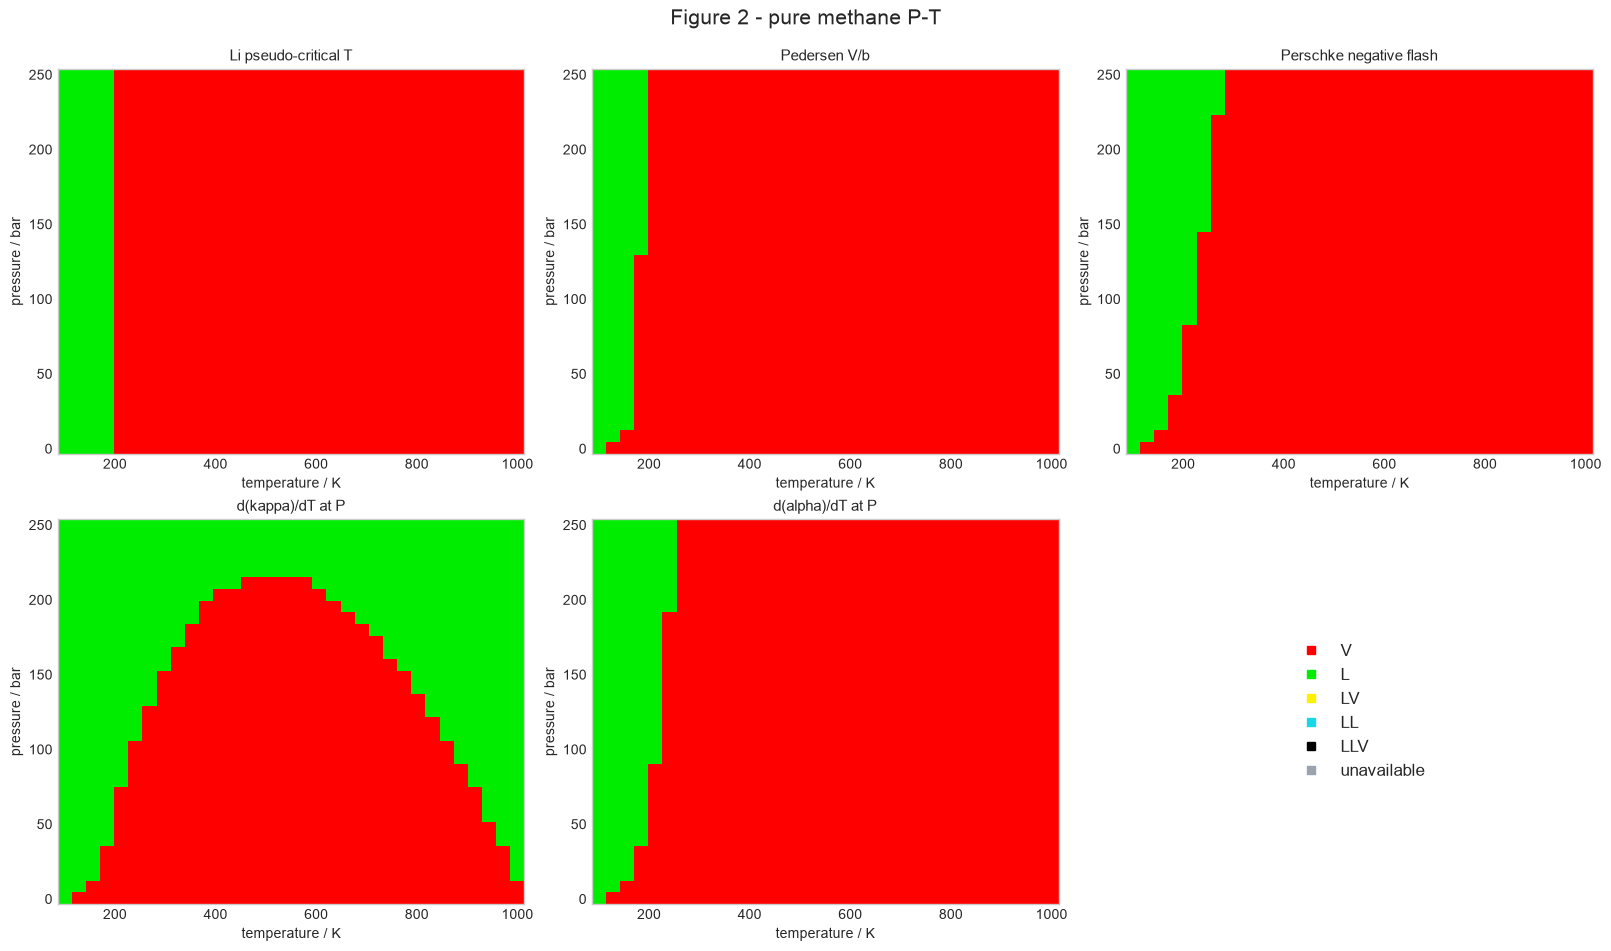

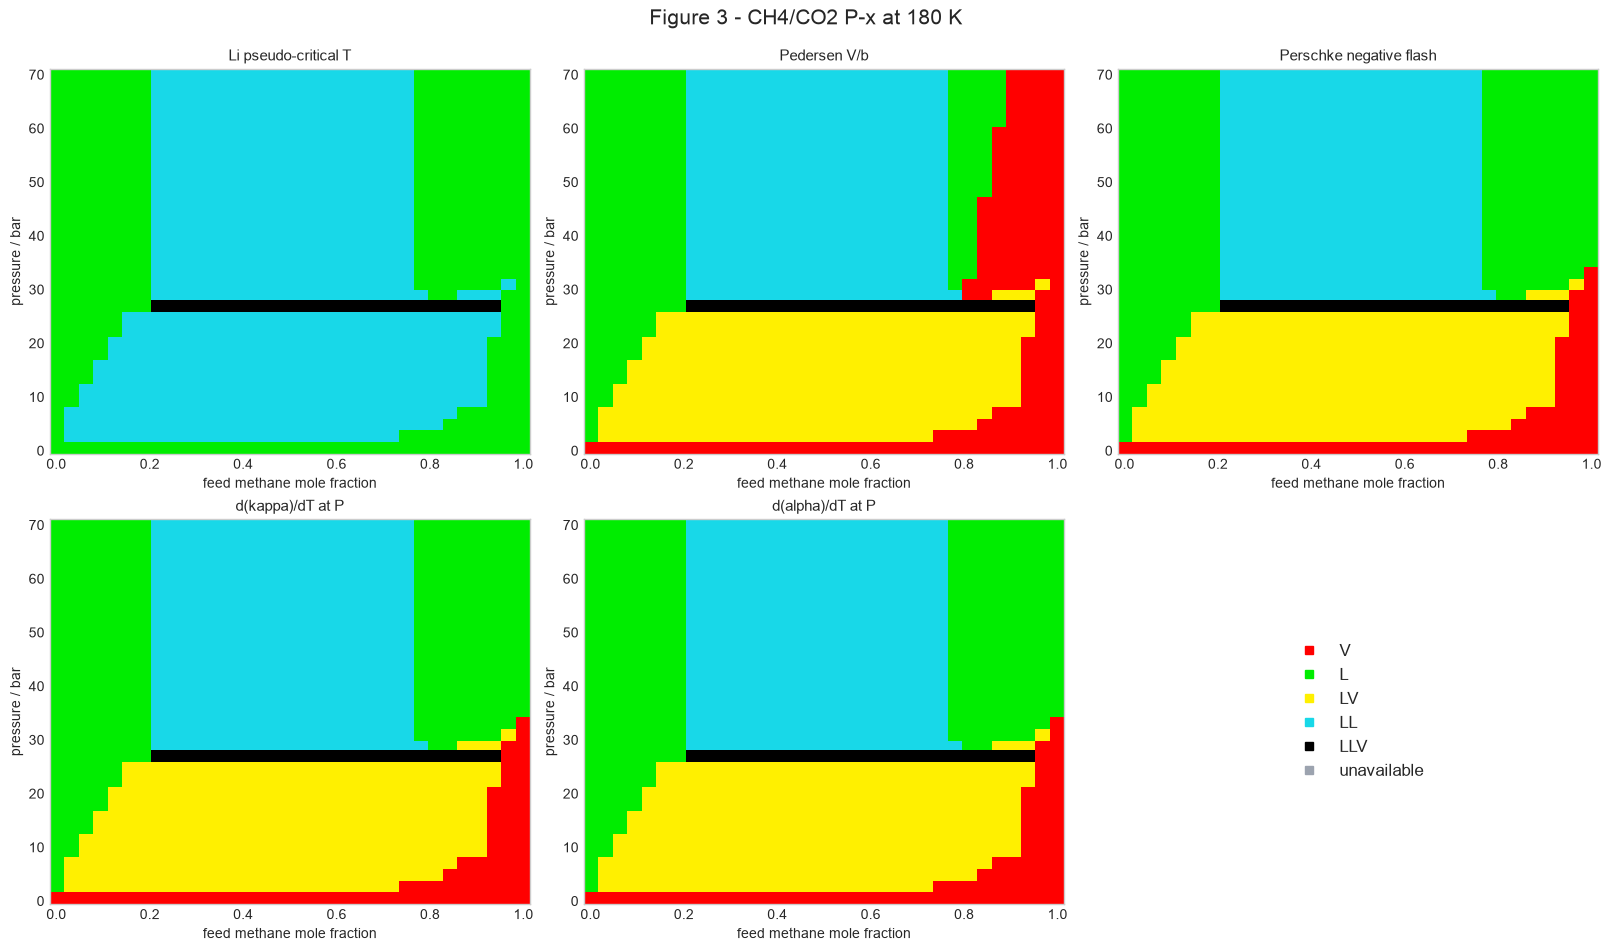

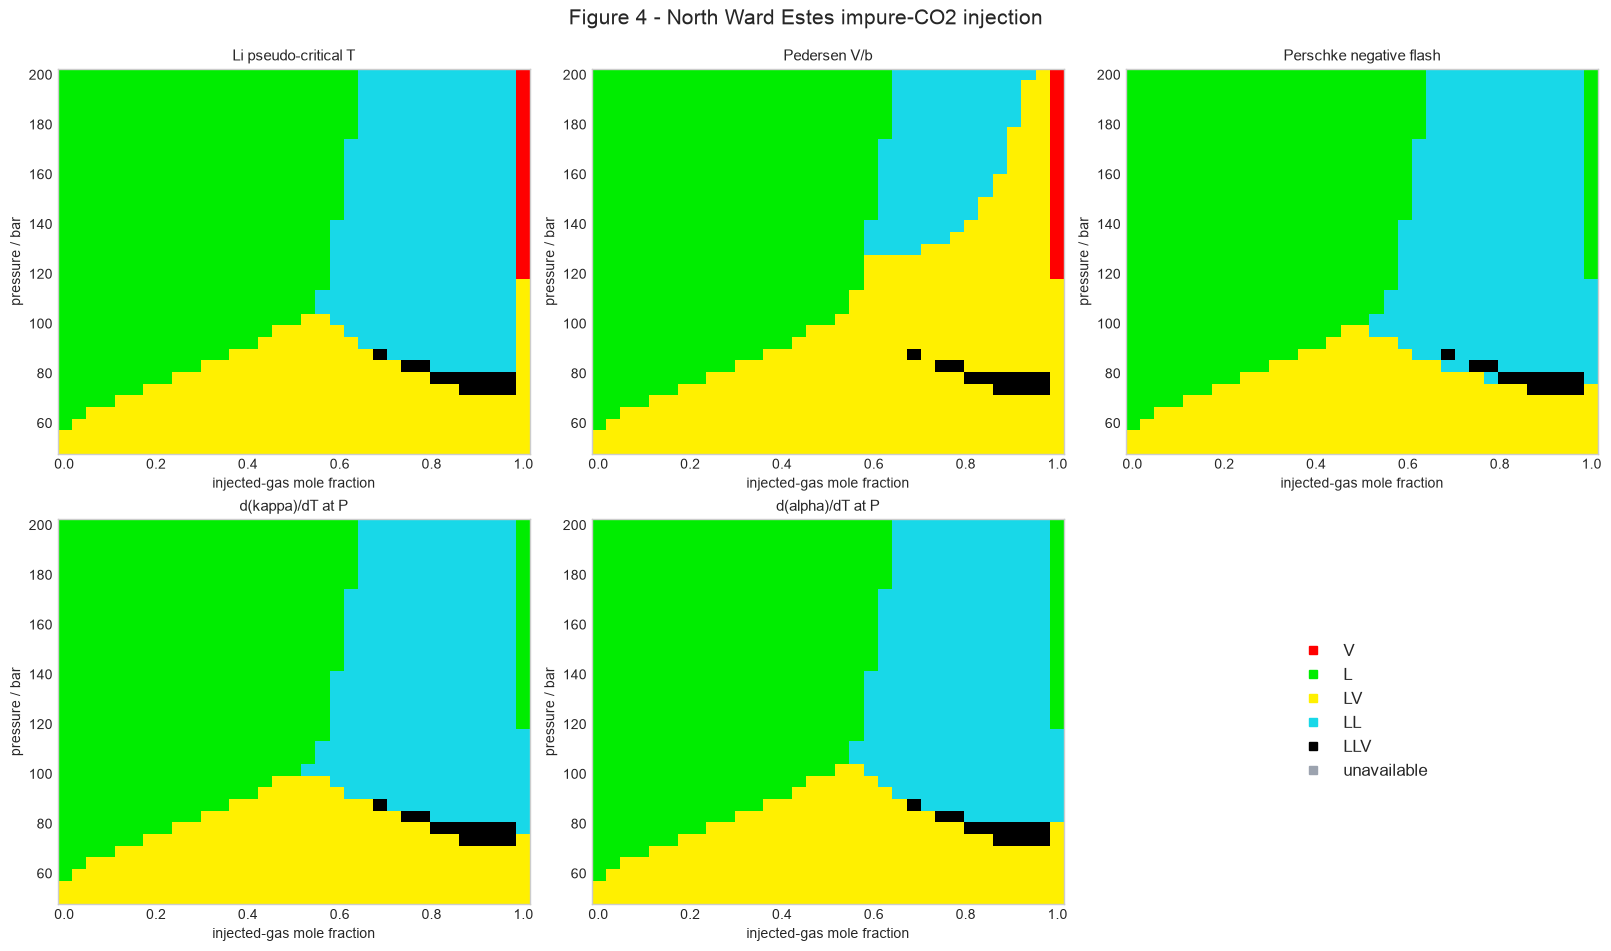

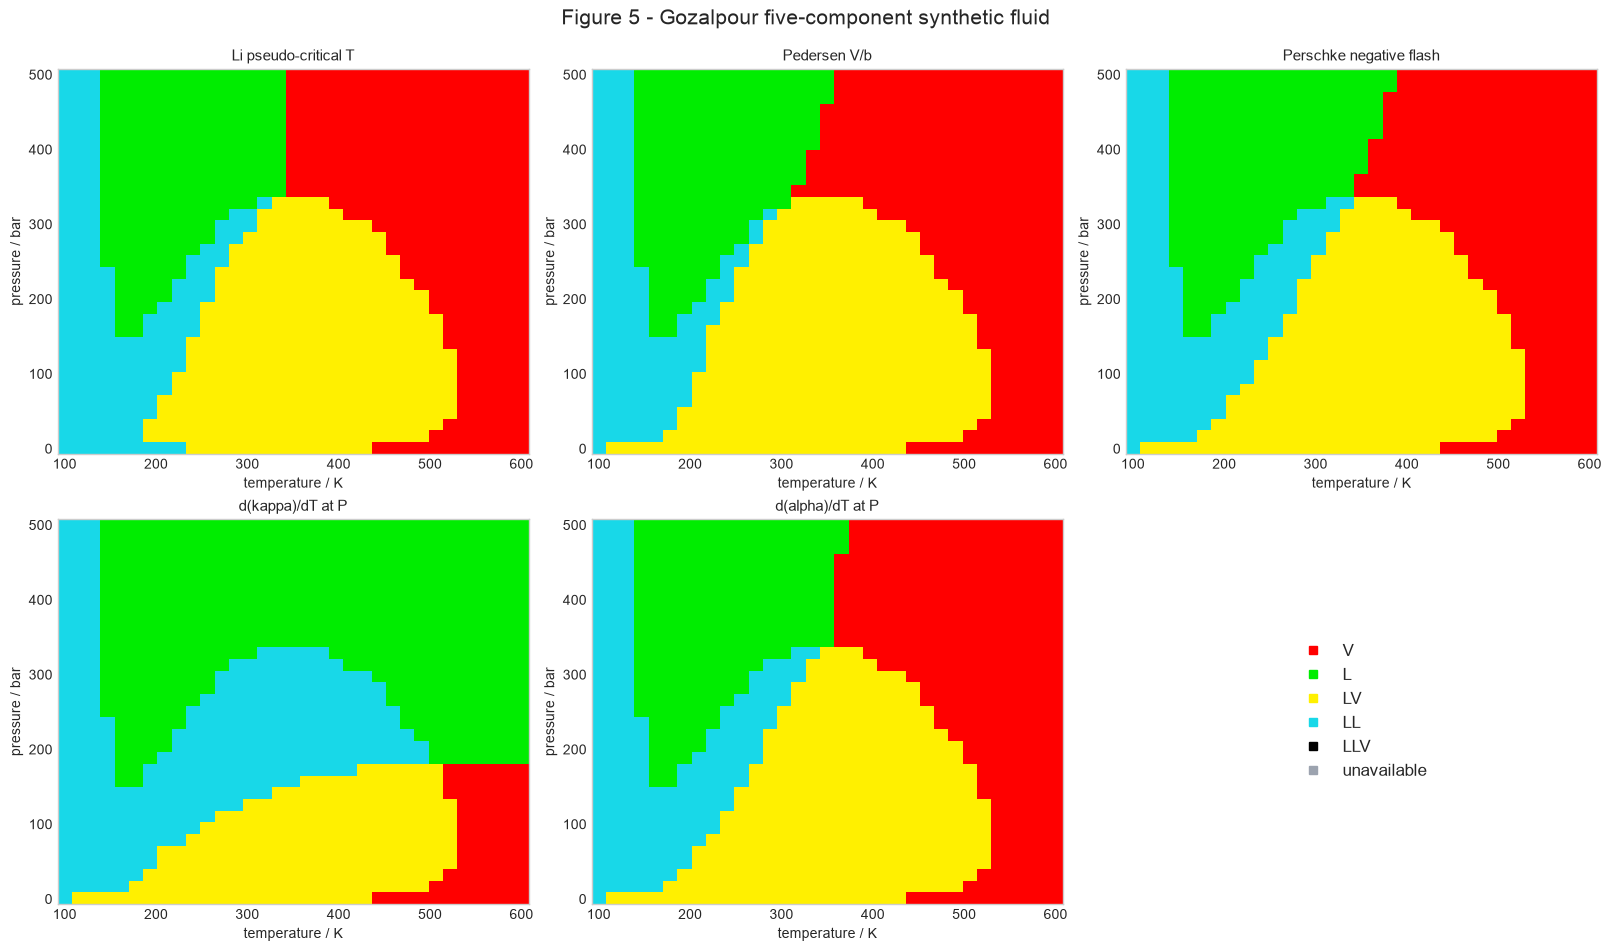

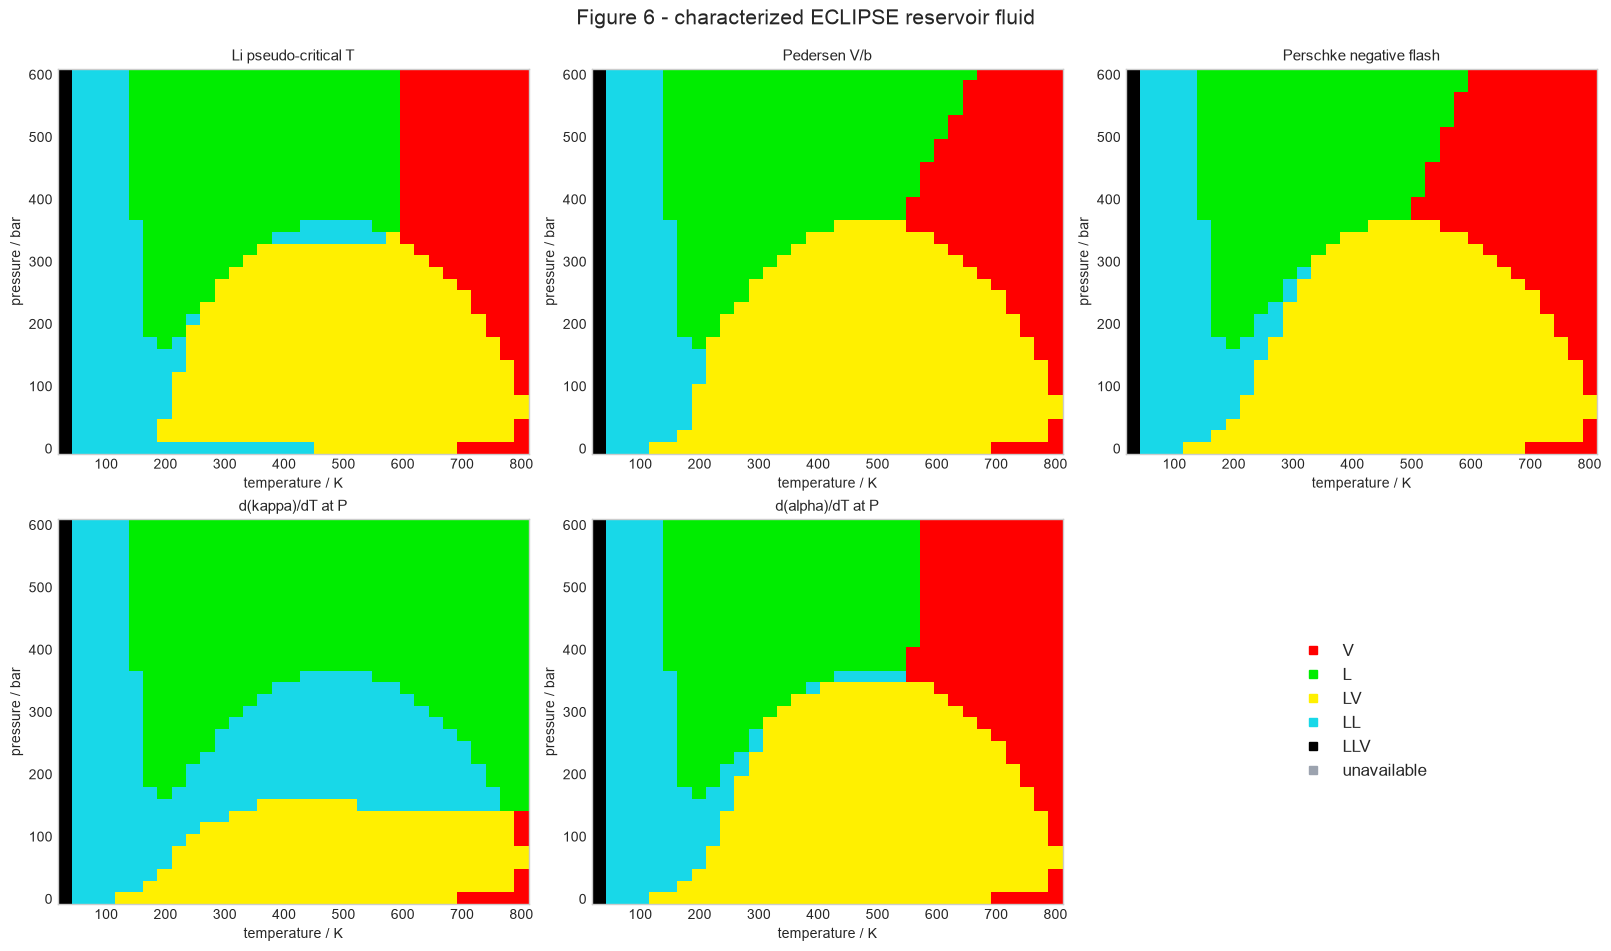

In [11]:
phase_cmap = ListedColormap(
    ["#ff0000", "#00ed00", "#fff000", "#18d8e8", "#000000", "#9ca3af"]
)
phase_norm = BoundaryNorm(np.arange(-0.5, 6.5), phase_cmap.N)


def plot_case(case: PaperCase, regions: dict[str, np.ndarray]) -> None:
    figure, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
    for axis, (method, phase_code) in zip(axes.flat, regions.items(), strict=False):
        axis.pcolormesh(
            case.horizontal.detach().numpy(),
            case.vertical_bar.detach().numpy(),
            phase_code,
            cmap=phase_cmap,
            norm=phase_norm,
            shading="nearest",
        )
        axis.set_title(method, fontsize=11)
        axis.set_xlabel(case.horizontal_label)
        axis.set_ylabel("pressure / bar")
    legend_axis = axes.flat[-1]
    legend_axis.axis("off")
    legend_axis.legend(
        handles=[
            plt.Line2D(
                [],
                [],
                marker="s",
                linestyle="",
                color=phase_cmap(code),
                label=label,
            )
            for label, code in PHASE_CODES.items()
        ],
        loc="center",
        fontsize=12,
    )
    figure.suptitle(case.name, fontsize=15, y=1.04)
    plt.show()


for current_case in CASES:
    plot_case(current_case, case_results[current_case.name])

## Quantitative map comparison

Pair agreement is the fraction of valid cells assigned the same complete
V/L/LV/LL/LLV code. Region fractions make missing or implausibly collapsed
multiphase structure visible; numerical availability alone is not treated as
reproduction evidence.

In [12]:
agreement_rows = []
for case in CASES:
    regions = case_results[case.name]
    all_values = np.stack(tuple(regions.values()))
    valid_all = (all_values != PHASE_CODES["unavailable"]).all(axis=0)
    disagreement = valid_all & (all_values.min(axis=0) != all_values.max(axis=0))
    for first_index, first in enumerate(METHODS):
        for second_index, second in enumerate(METHODS):
            if second_index <= first_index:
                continue
            valid = (regions[first] != PHASE_CODES["unavailable"]) & (
                regions[second] != PHASE_CODES["unavailable"]
            )
            pair_agreement = (
                np.mean(regions[first][valid] == regions[second][valid])
                if valid.any()
                else np.nan
            )
            agreement_rows.append(
                {
                    "case": case.name,
                    "method 1": first,
                    "method 2": second,
                    "pair agreement": pair_agreement,
                    "any-method disagreement": disagreement.mean(),
                }
            )

agreement_table = pd.DataFrame(agreement_rows)
display(
    agreement_table.groupby("case", as_index=False).agg(
        minimum_pair_agreement=("pair agreement", "min"),
        mean_pair_agreement=("pair agreement", "mean"),
        any_method_disagreement=("any-method disagreement", "first"),
    )
)

region_rows = []
for case in CASES:
    for method, values in case_results[case.name].items():
        valid = values != PHASE_CODES["unavailable"]
        for region, code in PHASE_CODES.items():
            if region == "unavailable":
                continue
            region_rows.append(
                {
                    "case": case.name,
                    "method": method,
                    "region": region,
                    "fraction of valid grid": np.mean(values[valid] == code),
                }
            )
display(
    pd.DataFrame(region_rows).pivot_table(
        index=["case", "method"],
        columns="region",
        values="fraction of valid grid",
    )
)

,case,minimum_pair_agreement,mean_pair_agreement,any_method_disagreement
0,Figure 2 - pure methane P-T,0.640037,0.845730,0.367309
1,Figure 3 - CH4/CO2 P-x at 180 K,0.565657,0.826263,0.434343
2,Figure 4 - North Ward Estes impure-CO2 injection,0.799816,0.914233,0.200184
3,Figure 5 - Gozalpour five-component synthetic ...,0.587695,0.824426,0.423324
4,Figure 6 - characterized ECLIPSE reservoir fluid,0.644628,0.835813,0.387511


region                                                                             L  \
case                                               method                              
Figure 2 - pure methane P-T                        Li pseudo-critical T     0.121212   
                                                   Pedersen V/b             0.102847   
                                                   Perschke negative flash  0.150597   
                                                   d(alpha)/dT at P         0.140496   
                                                   d(kappa)/dT at P         0.462810   
Figure 3 - CH4/CO2 P-x at 180 K                    Li pseudo-critical T     0.376492   
                                                   Pedersen V/b             0.212121   
                                                   Perschke negative flash  0.302112   
                                                   d(alpha)/dT at P         0.302112   
                                                   d(kappa)/dT at P         0.302112   
Figure 4 - North Ward Estes impure-CO2 injection   Li pseudo-critical T     0.463728   
                                                   Pedersen V/b             0.463728   
                                                   Perschke negative flash  0.480257   
                                                   d(alpha)/dT at P         0.480257   
                                                   d(kappa)/dT at P         0.480257   
Figure 5 - Gozalpour five-component synthetic f... Li pseudo-critical T     0.194674   
                                                   Pedersen V/b             0.192837   
                                                   Perschke negative flash  0.210285   
                                                   d(alpha)/dT at P         0.207530   
                                                   d(kappa)/dT at P         0.456382   
Figure 6 - characterized ECLIPSE reservoir fluid   Li pseudo-critical T     0.285583   
                                                   Pedersen V/b             0.287420   
                                                   Perschke negative flash  0.259871   
                                                   d(alpha)/dT at P         0.269972   
                                                   d(kappa)/dT at P         0.449954   

region                                                                            LL  \
case                                               method                              
Figure 2 - pure methane P-T                        Li pseudo-critical T     0.000000   
                                                   Pedersen V/b             0.000000   
                                                   Perschke negative flash  0.000000   
                                                   d(alpha)/dT at P         0.000000   
                                                   d(kappa)/dT at P         0.000000   
Figure 3 - CH4/CO2 P-x at 180 K                    Li pseudo-critical T     0.601469   
                                                   Pedersen V/b             0.331497   
                                                   Perschke negative flash  0.331497   
                                                   d(alpha)/dT at P         0.331497   
                                                   d(kappa)/dT at P         0.331497   
Figure 4 - North Ward Estes impure-CO2 injection   Li pseudo-critical T     0.281910   
                                                   Pedersen V/b             0.117539   
                                                   Perschke negative flash  0.301194   
                                                   d(alpha)/dT at P         0.289256   
                                                   d(kappa)/dT at P         0.293848   
Figure 5 - Gozalpour five-component synthetic f... Li pseudo-critical T     0.169881   
                                       

### Paper-topology regression gates

These gates encode the visually distinctive features of Figures 2-6. They
complement, rather than replace, direct inspection of the saved plots.

In [13]:
if GRID_POINTS >= 9:
    methane_regions = case_results[methane_case.name]
    binary_regions = case_results[binary_case.name]
    nwe_regions = case_results[nwe_case.name]
    synthetic_regions = case_results[synthetic_case.name]
    reservoir_regions = case_results[reservoir_case.name]

    assert PHASE_CODES["V"] in methane_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["L"] in methane_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["LL"] in binary_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LV"] not in binary_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LLV"] in binary_regions["Perschke negative flash"]
    assert PHASE_CODES["LV"] in synthetic_regions["Perschke negative flash"]
    assert PHASE_CODES["LL"] in synthetic_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["LLV"] in reservoir_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LL"] in reservoir_regions["Perschke negative flash"]
    if GRID_POINTS >= 17:
        # Figure 4's three-phase strip is narrower than the 9 x 9 smoke spacing.
        assert PHASE_CODES["LLV"] in nwe_regions["d(alpha)/dT at P"]

## Public-API audit on flashed phases

This table calls `identify_phase` itself, rather than only the lower-level
tensor diagnostics used to build the maps. As in the maps, its composition is
an equilibrium-phase composition returned by the grid flash, not the feed.
The stored criterion is in its native units: \(T/T_c\), \(V/b\), \(G(0.5)\),
1/(Pa K), or 1/K².

In [14]:
api_rows = []
for case in CASES:
    equilibrium = case_equilibria[case.name]
    flat_index = equilibrium.temperatures.numel() // 2
    if not bool(equilibrium.converged[flat_index]):
        raise RuntimeError(f"public-API audit flash failed for {case.name}")
    for phase_index in range(int(equilibrium.phase_counts[flat_index])):
        state = ChemicalState(
            equilibrium.temperatures[flat_index],
            equilibrium.pressures[flat_index],
            equilibrium.phase_compositions[flat_index, phase_index],
        )
        for label, method in METHODS.items():
            result = identify_phase(case.model, state, method=method)
            api_rows.append(
                {
                    "case": case.name,
                    "equilibrium phase": phase_index,
                    "method": label,
                    "identity": result.kind,
                    "criterion": (
                        np.nan
                        if result.criterion_value is None
                        else float(result.criterion_value.detach())
                    ),
                    "threshold": (
                        np.nan
                        if result.threshold is None
                        else float(result.threshold.detach())
                    ),
                    "ambiguous": result.ambiguous,
                }
            )

api_table = pd.DataFrame(api_rows)
display(api_table)
assert api_table["criterion"].notna().all()

,case,equilibrium phase,method,identity,criterion,threshold,ambiguous
0,Figure 2 - pure methane P-T,0,Li pseudo-critical T,vapor,2.886169e+00,1.00,False
1,Figure 2 - pure methane P-T,0,Pedersen V/b,vapor,1.375873e+01,1.75,False
2,Figure 2 - pure methane P-T,0,Perschke negative flash,vapor,1.710192e+00,0.00,False
3,Figure 2 - pure methane P-T,0,d(kappa)/dT at P,vapor,-7.788217e-12,0.00,True
4,Figure 2 - pure methane P-T,0,d(alpha)/dT at P,vapor,-4.911491e-06,0.00,False
5,Figure 3 - CH4/CO2 P-x at 180 K,0,Li pseudo-critical T,liquid,8.378605e-01,1.00,False
6,Figure 3 - CH4/CO2 P-x at 180 K,0,Pedersen V/b,liquid,1.693095e+00,1.75,True
7,Figure 3 - CH4/CO2 P-x at 180 K,0,Perschke negative flash,liquid,-4.670695e-01,0.00,False
8,Figure 3 - CH4/CO2 P-x at 180 K,0,d(kappa)/dT at P,liquid,8.264139e-10,0.00,False
9,Figure 3 - CH4/CO2 P-x at 180 K,0,d(alpha)/dT at P,liquid,2.941217e-04,0.00,False


## Higher-order autodiff audit

A trainable CH₄/CO₂ interaction is used to verify that Bennett's
\((\partial\alpha/\partial T)_P\) criterion remains connected to both the
temperature and model parameter graph. A nonzero finite interaction
gradient is the relevant differentiability gate.

In [15]:
gradient_model = peng_robinson_1978(
    binary_components,
    kij=binary_kij,
    trainable=True,
)
gradient_temperature = torch.tensor(180.0, requires_grad=True)
gradient_state = ChemicalState(
    gradient_temperature,
    torch.tensor(3.0e6),
    torch.tensor([0.5, 0.5]),
)
gradient_identification = identify_phase(
    gradient_model,
    gradient_state,
    method="bennett-thermal-expansion-derivative",
)
if gradient_identification.criterion_value is None:
    raise RuntimeError("thermal-expansion criterion unexpectedly unavailable")
temperature_gradient, interaction_gradient = torch.autograd.grad(
    gradient_identification.criterion_value,
    (gradient_temperature, gradient_model.mixing.raw_kij),
)
gradient_audit = pd.Series(
    {
        "criterion / K^-2": float(gradient_identification.criterion_value.detach()),
        "d criterion / dT / K^-3": float(temperature_gradient),
        "off-diagonal d criterion / dkij / K^-2": float(interaction_gradient[0, 1]),
        "all gradients finite": bool(
            torch.isfinite(temperature_gradient)
            & torch.isfinite(interaction_gradient).all()
        ),
    },
    name="value",
)
display(gradient_audit.to_frame())
assert bool(gradient_audit["all gradients finite"])
assert abs(float(interaction_gradient[0, 1])) > 0.0

,value
criterion / K^-2,0.000084
d criterion / dT / K^-3,0.000003
off-diagonal d criterion / dkij / K^-2,0.00011
all gradients finite,True


## Conclusions and limitations

- Every plotted cell is flashed first. Only converged equilibrium phase
  compositions that pass fugacity and material-balance gates are passed to
  the five identification criteria.
- The five maps recover the paper's defining topology and method-specific
  differences: the methane compressibility dome, binary LV/LL divider,
  North Ward Estes three-phase band, synthetic-fluid envelope, and the
  reservoir-fluid low-temperature LLV/LL strips.
- The derivative methods use second-order PyTorch autodiff and retain a
  gradient to trainable EoS interactions.
- The North Ward Estes case derives missing critical volumes consistently
  from PR. The ECLIPSE table omits the complete EOS/BIC input; Figure 6 is
  therefore labeled as the transparent
  `bennett-figure6-reconstruction-v1`, not as the unpublished ECLIPSE
  parameterization.
- These results are **verification of the implemented diagnostics**, not
  validation against experimental phase labels. The saved 33 by 33 maps
  resolve the topology; they are not pixel-wise validation of the paper's 500 by 500
  raster.

For a denser study, set `TORCH_FLASH_PHASE_ID_GRID_POINTS` before execution.
The paper reports rerunning illustrative plots on 500 by 500 grids; that
profile is intentionally not the default because the strict flash residual
gates make it substantially more expensive.